# 红外图像 1/f 条纹噪声校正

本 Notebook 按《科创任务安排.docx》中“主要工作”的原始顺序分为九段，并在最后批量生成交付产品。

设计原则：原始 FITS 是唯一科学输入；星源、blindmap 和边缘像元只用于排除条纹估计；输出满足
`corrected = original - flicker_model`。老师说明 DQ 是由 blindmap 生成且本任务不需要，因此这里不生成、
不读取独立 DQ：直接合并 `DeadBlindMap.tiff` 与 `NoiseBlindMap.tiff` 形成 detector mask。

## 0. 环境、路径与参数

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

start = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (start, *start.parents) if (path / "src" / "astr_ir").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("无法定位项目根目录；请在 Astr_IR 项目内运行 Notebook")
DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "our_dataset"
OUTPUT_ROOT = PROJECT_ROOT / "data" / "processed" / "flicker"
FIGURE_ROOT = PROJECT_ROOT / "figures" / "flicker_output"
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from astr_ir.flicker.processor import (
    FlickerConfig, correct_flicker, load_detector_mask, load_fits,
    load_measurement_table, run_batch, target_record_for_file,
)
from astr_ir.flicker.visualization import (
    plot_background_stage, plot_correction_overview,
    plot_direction_diagnostics, plot_masks_and_background,
    plot_photometry_changes, plot_power_spectrum,
    plot_profiles_before_after, save_figure,
)

config = FlickerConfig(
    direction="auto",
    profile_smooth_size=5,
)
RUN_FULL_BATCH = True
OVERWRITE_PRODUCTS = True
config

FlickerConfig(direction='auto', edge_width=24, background_block_size=64, background_smooth_sigma_blocks=1.25, sigma_clip=3.0, sigma_clip_iters=5, profile_smooth_size=5, source_sigma=6.0, source_dilation=8, known_source_radius_scale=1.25, min_direction_score=1.6, min_relative_improvement=0.3, max_noise_increase=0.02, photometry_gate_snr=10.0, max_photometry_change=0.01)

In [2]:
detector_mask = load_detector_mask(DATASET_ROOT / "盲点表")
measurement_table = load_measurement_table(DATASET_ROOT / "单帧检测总表_新方法.csv")
sample_path = sorted((DATASET_ROOT / "90000003").glob("*.fits"))[0]
image, header = load_fits(sample_path)
target = target_record_for_file(measurement_table, sample_path.name)
result = correct_flicker(image, detector_mask=detector_mask, target=target, config=config)
print("示例帧:", sample_path.name)
print("图像尺寸:", image.shape, "EXPOSURE:", header.get("EXPOSURE"))

示例帧: IR01_RKZ50_SCIE_20260315132820958.fits
图像尺寸: (1024, 1024) EXPOSURE: 1.0


## 主要工作 1/9：检查条纹主要沿行方向还是列方向

水平条纹对应“每行偏置随 y 变化”，记为 `row`；垂直条纹对应“每列偏置随 x 变化”，记为 `column`。
自动方向分数为 Sigma 裁剪剖面的稳健标准差除以中位数统计误差，并比较扣除统计误差后的信号幅度。

,方向,score,signal_std
0,row / 水平条纹,3.689535,34.753807
1,column / 垂直条纹,2.205820,19.409424


自动选择: row


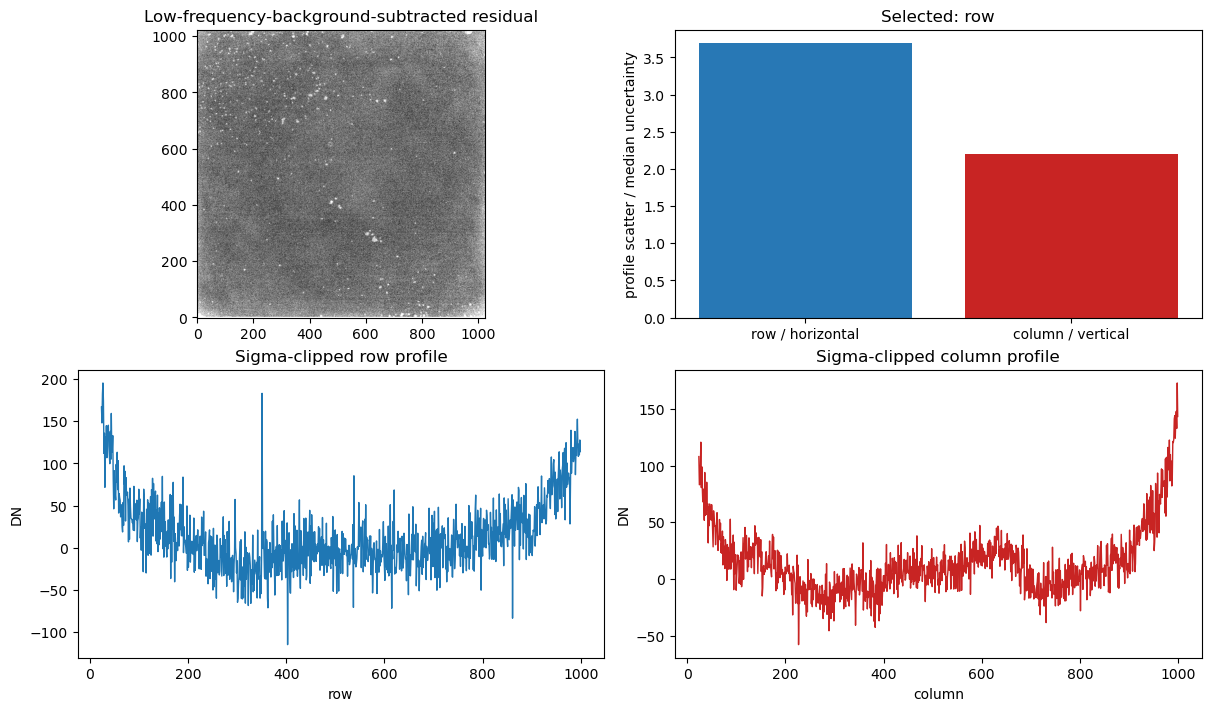

In [3]:
direction_table = pd.DataFrame([
    {"方向": "row / 水平条纹", "score": result.row_diagnostic.score,
     "signal_std": result.row_diagnostic.signal_std},
    {"方向": "column / 垂直条纹", "score": result.column_diagnostic.score,
     "signal_std": result.column_diagnostic.signal_std},
])
display(direction_table)
print("自动选择:", result.selected_direction)
fig = plot_direction_diagnostics(result)
save_figure(fig, FIGURE_ROOT / "01_direction_diagnostic.png")
plt.show()

## 主要工作 2/9：合并星源、DQ 和边缘掩膜

本数据没有必要再构造 DQ。`detector_mask = DeadBlindMap OR NoiseBlindMap`；再与 CSV 目标星圆形掩膜、
自动紧致源掩膜、边缘 24 像素和非有限像元合并。所有这些像元不参与条纹估计，但条纹模型仍可在全图上计算。

,masked pixels
detector blindmap union,4801
known + auto sources,2807
edge,96000
combined (union),102357


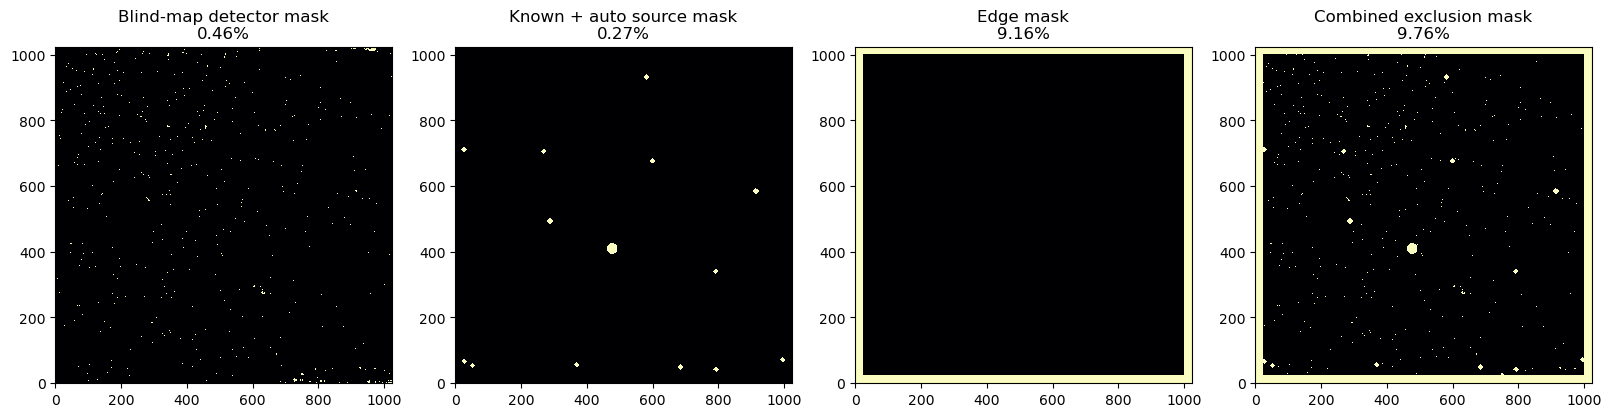

In [4]:
mask_summary = pd.Series({
    "detector blindmap union": result.detector_mask.sum(),
    "known + auto sources": result.source_mask.sum(),
    "edge": result.edge_mask.sum(),
    "combined (union)": result.combined_mask.sum(),
}, name="masked pixels")
display(mask_summary.to_frame())
fig = plot_masks_and_background(result)
save_figure(fig, FIGURE_ROOT / "02_masks.png")
plt.show()

## 主要工作 3/9：先估计并减去低频二维背景

将未掩膜像元按 64×64 分块取中位数，在粗网格上高斯平滑后插值回原尺寸。该背景仅用于隔离条纹；
最终代数关系仍是原图减条纹模型，因此不会把天文低频背景当作输出扣除项。

background median: 43050.0768260424
residual robust std: 256.9323217256034


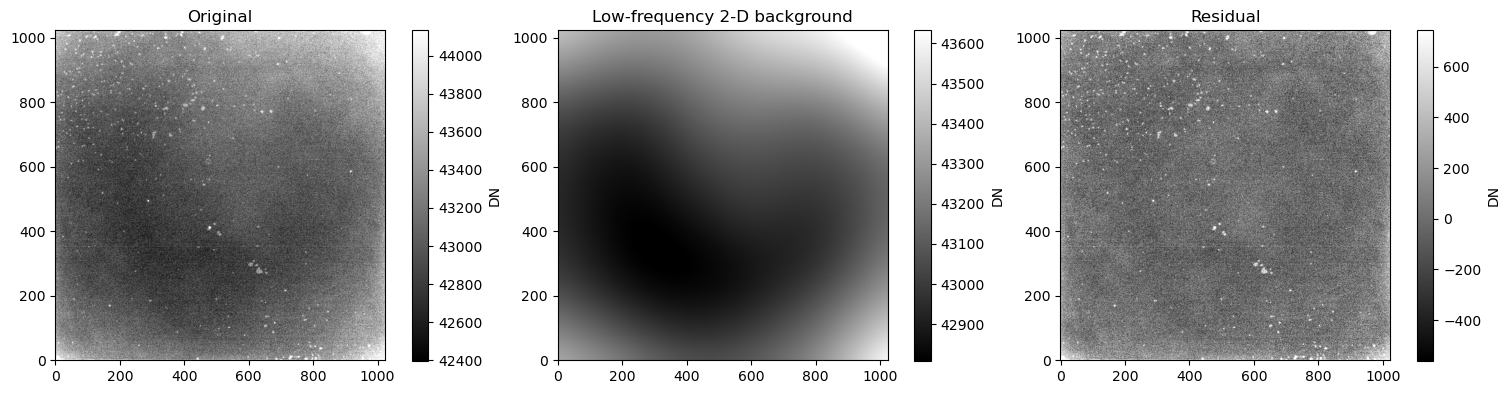

In [5]:
print("background median:", np.median(result.low_frequency_background))
print("residual robust std:", 1.4826 * np.median(np.abs(result.residual - np.median(result.residual))))
fig = plot_background_stage(result)
save_figure(fig, FIGURE_ROOT / "03_low_frequency_background.png")
plt.show()

## 主要工作 4/9：对未掩膜像元计算每行或每列的 Sigma 裁剪中位数

两个方向都计算，便于诊断；真正的候选条纹模型只使用自动或手动选择的方向。

In [6]:
selected_diag = result.row_diagnostic if result.selected_direction == "row" else result.column_diagnostic
profile_stats = pd.Series({
    "profile length": len(selected_diag.profile),
    "median valid pixels per line": np.median(selected_diag.valid_count),
    "profile robust std": selected_diag.robust_std,
    "median uncertainty": selected_diag.noise_floor,
    "direction score": selected_diag.score,
})
display(profile_stats.to_frame("value"))

,value
profile length,1024.000000
median valid pixels per line,972.000000
profile robust std,36.105265
median uncertainty,9.785859
direction score,3.689535


## 主要工作 5/9：对一维条纹序列进行中值低通平滑

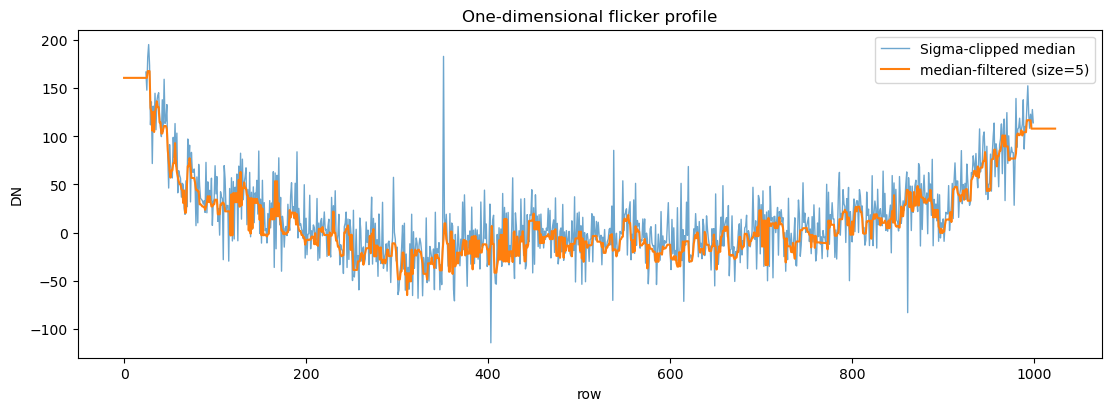

In [7]:
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
ax.plot(selected_diag.profile, label="Sigma-clipped median", lw=1, alpha=0.65)
ax.plot(result.smoothed_profile, label=f"median-filtered (size={config.profile_smooth_size})", lw=1.5)
ax.set(xlabel=result.selected_direction, ylabel="DN", title="One-dimensional flicker profile")
ax.legend()
save_figure(fig, FIGURE_ROOT / "05_smoothed_profile.png")
plt.show()

## 主要工作 6/9：将一维序列扩展为二维条纹模型

model shape: (1024, 1024)
model median/min/max: 0.0 -65.0098000232374 167.81300417642524


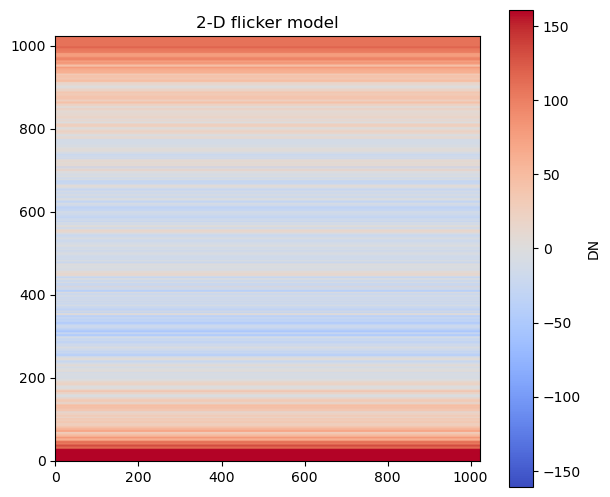

In [8]:
print("model shape:", result.flicker_model.shape)
print("model median/min/max:", np.median(result.flicker_model), result.flicker_model.min(), result.flicker_model.max())
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
lim = np.percentile(np.abs(result.flicker_model), 99)
im = ax.imshow(result.flicker_model, origin="lower", cmap="coolwarm", vmin=-lim, vmax=lim)
ax.set_title("2-D flicker model")
fig.colorbar(im, ax=ax, label="DN")
save_figure(fig, FIGURE_ROOT / "06_flicker_model.png")
plt.show()

## 主要工作 7/9：从图像扣除条纹，再恢复低频背景

实现等价于 `(original - background - model) + background`，即严格的 `corrected = original - model`。
弱条纹或质量门失败时，模型置零并返回“不需要校正”或具体拒绝原因，绝不强行扣除。

,value
direction_requested,auto
selected_direction,row
applied,True
status,corrected
row_score,3.689535
column_score,2.20582
direction_score,3.689535
profile_rstd_before,36.105265
profile_rstd_after,15.817172
relative_reduction,0.561915


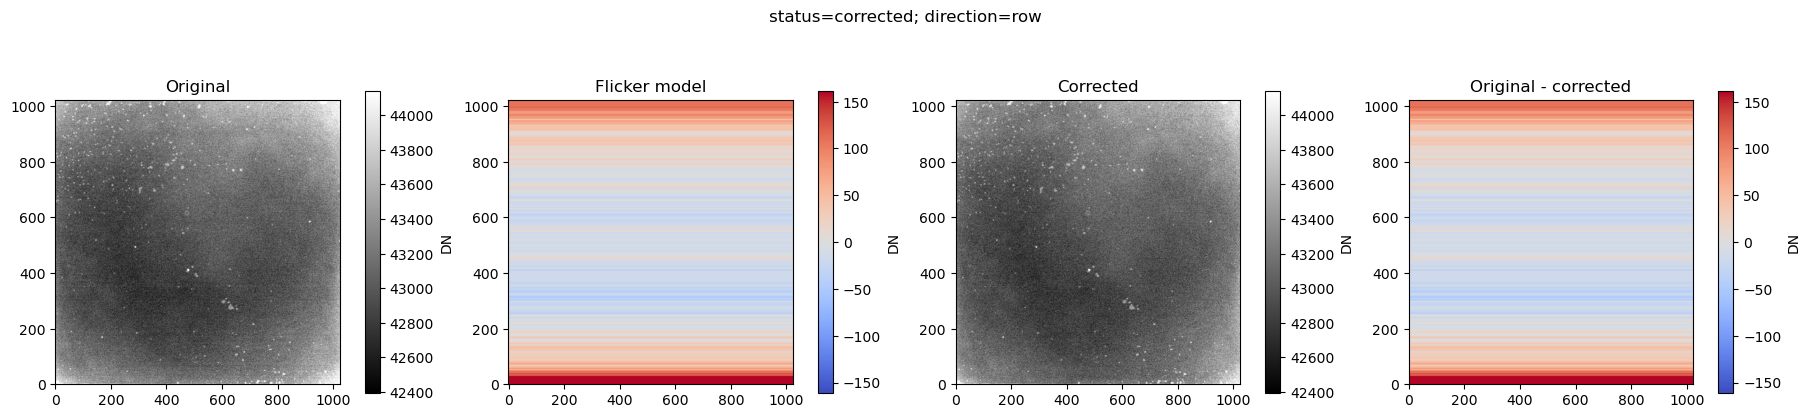

In [9]:
equation_error = np.max(np.abs(result.corrected - (result.original - result.flicker_model)))
display(pd.Series({**result.metrics, "float64 equation max abs error": equation_error}).to_frame("value"))
fig = plot_correction_overview(result)
save_figure(fig, FIGURE_ROOT / "07_correction_overview.png")
plt.show()

## 主要工作 8/9：比较校正前后的行列中位数和一维功率谱

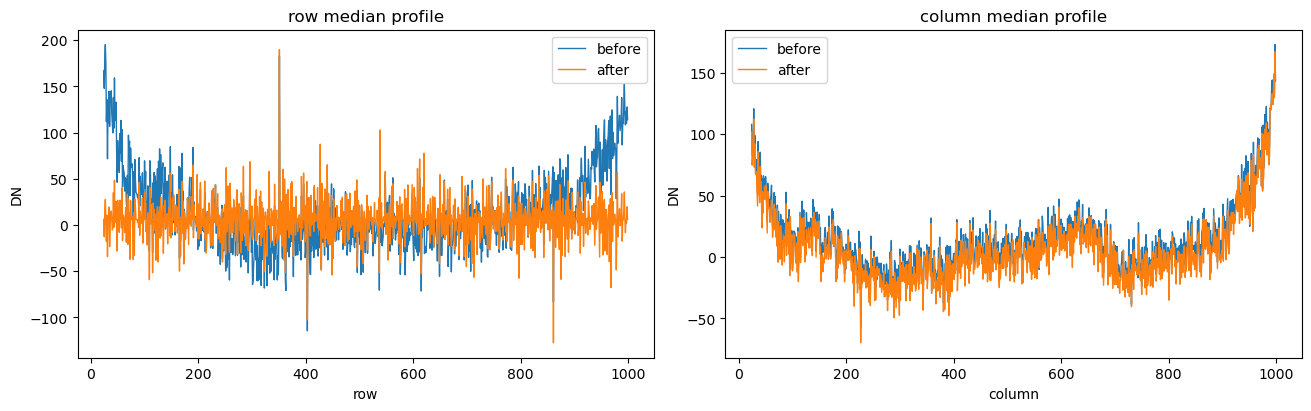

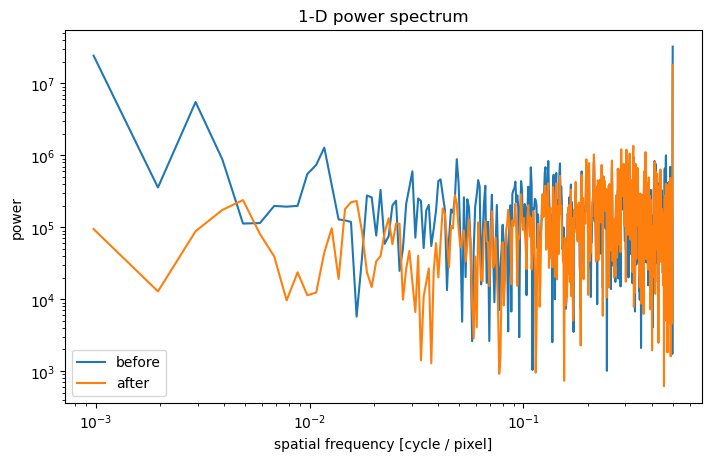

selected-profile robust-std reduction: 56.19%


In [10]:
fig = plot_profiles_before_after(result)
save_figure(fig, FIGURE_ROOT / "08_profiles_before_after.png")
plt.show()
fig = plot_power_spectrum(result)
save_figure(fig, FIGURE_ROOT / "08_power_spectrum.png")
plt.show()
print("selected-profile robust-std reduction:", f"{100 * result.metrics['relative_reduction']:.2f}%")

## 主要工作 9/9：检查恒星测光是否受到影响

使用 CSV 中 `xc/yc/r_ap/r_in/r_out` 重做圆孔径测光。SNR≥10 的正常恒星启用 1% 质量门；
低信噪比帧仍记录测光差异，但不以不稳定的相对百分比否决条纹校正。

In [11]:
display(pd.Series({
    "input SNR": target["snr"],
    "aperture flux before": result.metrics["photometry_before"],
    "aperture flux after": result.metrics["photometry_after"],
    "relative change [%]": 100 * result.metrics["photometry_change_fraction"],
    "photometry gate active": result.metrics["photometry_gate_active"],
}).to_frame("value"))

,value
input SNR,70.1933
aperture flux before,312410.5
aperture flux after,314341.692928
relative change [%],0.618159
photometry gate active,True


## 10. 批量生成输出产品并汇总验收指标

每个原始 FITS 输出 `flicker_corrected_*.fits` 和 `flicker_model_*.fits`；完整保留并规范化原科学头，
数据统一写为 float32。全数据集统计写入 `data/processed/flicker/flicker_statistics.csv`。

In [12]:
if RUN_FULL_BATCH:
    stats = run_batch(
        DATASET_ROOT,
        OUTPUT_ROOT,
        config=config,
        overwrite=OVERWRITE_PRODUCTS,
    )
else:
    stats_path = OUTPUT_ROOT / "flicker_statistics.csv"
    stats = pd.read_csv(stats_path, encoding="utf-8-sig")

display(stats.groupby(["sequence", "status"]).size().rename("frames").to_frame())

frames
sequence status                            
90000002 corrected                       80
90000003 corrected                       76
         rejected_photometry_change       4

,value
total frames,160.000000
corrected frames,156.000000
not corrected frames,4.000000
min reduction among corrected [%],49.113510
corrected frames meeting >=30%,156.000000
max background-noise ratio,1.000448
normal-star frames (SNR>=10),80.000000
max |normal-star flux change| [%],0.972175
max float32 equation error,0.000000


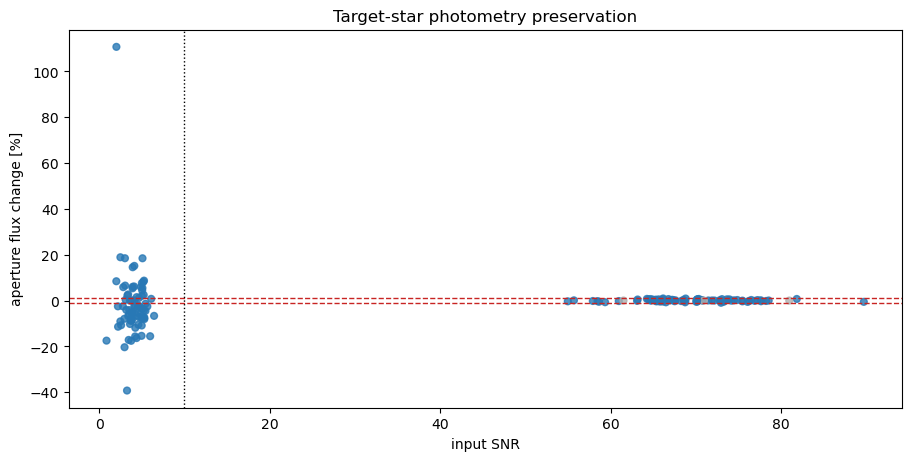

In [13]:
applied = stats[stats["applied"].astype(bool)]
normal_stars = stats[stats["input_snr"] >= config.photometry_gate_snr]
acceptance = pd.Series({
    "total frames": len(stats),
    "corrected frames": len(applied),
    "not corrected frames": len(stats) - len(applied),
    "min reduction among corrected [%]": 100 * applied["relative_reduction"].min(),
    "corrected frames meeting >=30%": int((applied["relative_reduction"] >= 0.30).sum()),
    "max background-noise ratio": applied["background_noise_ratio"].max(),
    "normal-star frames (SNR>=10)": len(normal_stars),
    "max |normal-star flux change| [%]": 100 * normal_stars["photometry_change_fraction"].abs().max(),
    "max float32 equation error": stats["equation_max_abs_error_float32"].max(),
})
display(acceptance.to_frame("value"))
fig = plot_photometry_changes(stats, snr_min=config.photometry_gate_snr)
save_figure(fig, FIGURE_ROOT / "09_all_frame_photometry.png")
plt.show()

## 11. 自动测试

测试覆盖行/列方向识别、弱条纹不校正、恒等式、恒星测光、手动方向、blindmap 合并和 FITS 头保留。

In [14]:
import subprocess
completed = subprocess.run(
    [sys.executable, "-m", "pytest", "-q"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    check=False,
)
print(completed.stdout)
if completed.stderr.strip():
    print("STDERR:")
    print(completed.stderr)
if completed.returncode != 0:
    raise RuntimeError(
        f"pytest failed with exit code {completed.returncode}; "
        "see the detailed output above"
    )

................                                                         [100%]
16 passed in 1.95s

